In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

In [2]:
wu_cells = pd.read_csv('./Data_Wu2021_Breast/Cells.csv', low_memory=False).astype(str)
wu_cells

,cell_name,sample,cell_type,cell_subtype,celltype_subset,patient,disease,gender,age,grade,...,PR,HER2_IHC,HER2_ISH_ratio,Ki67,subtype_IHC,treatment,details_treatment,notable_pathological_features,stage,complexity
0,CID3586_AAGACCTCAGCATGAG,CID3586,Endothelial,Endothelial ACKR1,Endothelial ACKR1,CID3586,HER2+,Female,43.0,3.0,...,100% 2-3+,3+,Amplified (6.8),30-50%,HER2+/ER+,Naïve,-,Multifocal tumour with associatied high grade ...,"pT(m)2, N2a",1689
1,CID3586_AAGGTTCGTAGTACCT,CID3586,Endothelial,Endothelial ACKR1,Endothelial ACKR1,CID3586,HER2+,Female,43.0,3.0,...,100% 2-3+,3+,Amplified (6.8),30-50%,HER2+/ER+,Naïve,-,Multifocal tumour with associatied high grade ...,"pT(m)2, N2a",779
2,CID3586_ACCAGTAGTTGTGGCC,CID3586,Endothelial,Endothelial ACKR1,Endothelial ACKR1,CID3586,HER2+,Female,43.0,3.0,...,100% 2-3+,3+,Amplified (6.8),30-50%,HER2+/ER+,Naïve,-,Multifocal tumour with associatied high grade ...,"pT(m)2, N2a",514
3,CID3586_ACCCACTAGATGTCGG,CID3586,Endothelial,Endothelial ACKR1,Endothelial ACKR1,CID3586,HER2+,Female,43.0,3.0,...,100% 2-3+,3+,Amplified (6.8),30-50%,HER2+/ER+,Naïve,-,Multifocal tumour with associatied high grade ...,"pT(m)2, N2a",609
4,CID3586_ACTGATGGTCAACTGT,CID3586,Endothelial,Endothelial ACKR1,Endothelial ACKR1,CID3586,HER2+,Female,43.0,3.0,...,100% 2-3+,3+,Amplified (6.8),30-50%,HER2+/ER+,Naïve,-,Multifocal tumour with associatied high grade ...,"pT(m)2, N2a",807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100059,CID4398_TCAGGTAGTACTCAAC,CID4398,Dendritic,DCs,Myeloid_c0_DC_LAMP3,CID4398,ER+,Female,52.0,3.0,...,80% 2+,2+,Non-Amplified,0.75,ER+,Treated,Neoadjuvant FEC-D,Mixed morphology with associated high grade DC...,"pT3, pN2a, pMx, Stage IIIA",1251
100060,CID4398_TCTATTGTCGCCATAA,CID4398,Dendritic,DCs,Myeloid_c0_DC_LAMP3,CID4398,ER+,Female,52.0,3.0,...,80% 2+,2+,Non-Amplified,0.75,ER+,Treated,Neoadjuvant FEC-D,Mixed morphology with associated high grade DC...,"pT3, pN2a, pMx, Stage IIIA",719
100061,CID4398_TCTTTCCCAGTAAGCG,CID4398,Dendritic,DCs,Myeloid_c0_DC_LAMP3,CID4398,ER+,Female,52.0,3.0,...,80% 2+,2+,Non-Amplified,0.75,ER+,Treated,Neoadjuvant FEC-D,Mixed morphology with associated high grade DC...,"pT3, pN2a, pMx, Stage IIIA",887
100062,CID4398_TGCCCATGTTACGGAG,CID4398,Dendritic,DCs,Myeloid_c0_DC_LAMP3,CID4398,ER+,Female,52.0,3.0,...,80% 2+,2+,Non-Amplified,0.75,ER+,Treated,Neoadjuvant FEC-D,Mixed morphology with associated high grade DC...,"pT3, pN2a, pMx, Stage IIIA",870


In [3]:
wu_genes = pd.read_csv('./Data_Wu2021_Breast/Genes.txt', header=None).astype(str)
wu_genes

,0
0,RP11-34P13.7
1,FO538757.3
2,FO538757.2
3,AP006222.2
4,RP4-669L17.10
...,...
29728,RP11-983C2.3
29729,LINC00919
29730,RP11-589P10.7
29731,KRTAP9-2


In [4]:
qian_cells = pd.read_csv('./Data_Qian2020_Breast/Cells.csv', low_memory=False).astype(str)
qian_cells

,cell_name,sample,cell_type,subclone,complexity
0,sc5rJUQ026_AAACCTGCATCTCGCT,42,T_cell,0,2138
1,sc5rJUQ026_AAACCTGGTTCTCATT,42,T_cell,0,2085
2,sc5rJUQ026_AAACCTGTCAAGAAGT,42,T_cell,0,1767
3,sc5rJUQ026_AAACCTGTCTCGCATC,42,T_cell,0,2016
4,sc5rJUQ026_AAACGGGAGTTATCGC,42,T_cell,0,1595
...,...,...,...,...,...
16532,sc5rJUQ064_TTTGGTTTCTGCCCTA,54,Malignant,1,2324
16533,sc5rJUQ064_TTTGTCAAGCCAGAAC,54,Malignant,1,2964
16534,sc5rJUQ064_TTTGTCAAGGACGAAA,54,Malignant,1,1814
16535,sc5rJUQ064_TTTGTCAGTCTTGTCC,54,Malignant,1,2464


In [5]:
qian_genes = pd.read_csv('./Data_Qian2020_Breast/Genes.txt', header=None).astype(str)
qian_genes

,0
0,FAM138A
1,OR4F5
2,OR4F29
3,OR4F16
4,FAM87B
...,...
22271,PCNT
22272,DIP2A
22273,S100B
22274,PRMT2


In [6]:
wu_cells['cell_type'].unique()

array(['Endothelial', 'Fibroblast', 'Pericyte', 'B_cell', 'T_cell',
       'NK_cell', 'Macrophage', 'Monocyte', 'Myeloid', 'Dendritic',
       'Epithelial', 'Plasmablast', 'Malignant'], dtype=object)

In [7]:
qian_cells['cell_type'].unique()

array(['T_cell', 'Fibroblast', 'Macrophage', 'Malignant', 'B_cell',
       'Endothelial', 'nan', 'Mast', 'Dendritic'], dtype=object)

In [8]:
common_genes = list(
    set(wu_genes[0].astype(str).values) &
    set(qian_genes[0].astype(str).values)
)
len(common_genes)

19954

In [9]:
from scipy import io
X_wu = io.mmread('./Data_Wu2021_Breast/Exp_data_UMIcounts.mtx').T.tocsr()
adata_wu = sc.AnnData(X_wu)
adata_wu.obs = wu_cells
adata_wu.obs.index = wu_cells['cell_name'].astype(str).values
adata_wu.var.index = wu_genes[0].astype(str).values
adata_wu = adata_wu[:, adata_wu.var.index.isin(common_genes)]
adata_wu = adata_wu[adata_wu.obs['cell_type'].isin(['T_cell', 'Fibroblast', 'Macrophage', 'Malignant', 'B_cell', 'Endothelial', 'Dendritic'])]
adata_wu

/data1/miniconda3/envs/research/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


View of AnnData object with n_obs × n_vars = 82125 × 19954
    obs: 'cell_name', 'sample', 'cell_type', 'cell_subtype', 'celltype_subset', 'patient', 'disease', 'gender', 'age', 'grade', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH_ratio', 'Ki67', 'subtype_IHC', 'treatment', 'details_treatment', 'notable_pathological_features', 'stage', 'complexity'

In [10]:
from scipy import io
X_qian = io.mmread('./Data_Qian2020_Breast/Exp_data_UMIcounts.mtx').T.tocsr()
adata_qian = sc.AnnData(X_qian)
adata_qian.obs = qian_cells
adata_qian.obs.index = qian_cells['cell_name'].astype(str).values
adata_qian.var.index = qian_genes[0].astype(str).values
adata_qian = adata_qian[:, adata_qian.var.index.isin(common_genes)]
adata_qian = adata_qian[adata_qian.obs['cell_type'].isin(['T_cell', 'Fibroblast', 'Macrophage', 'Malignant', 'B_cell', 'Endothelial', 'Dendritic'])]
adata_qian

/data1/miniconda3/envs/research/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


View of AnnData object with n_obs × n_vars = 15445 × 19954
    obs: 'cell_name', 'sample', 'cell_type', 'subclone', 'complexity'

In [11]:
adata_wu.layers["counts"] = adata_wu.X.copy()

/tmp/ipykernel_481595/2537409952.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_wu.layers["counts"] = adata_wu.X.copy()


In [12]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_wu)
# Logarithmize the data
sc.pp.log1p(adata_wu)

In [13]:
adata_qian.layers["counts"] = adata_qian.X.copy()

/tmp/ipykernel_481595/2495784095.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_qian.layers["counts"] = adata_qian.X.copy()


In [14]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_qian)
# Logarithmize the data
sc.pp.log1p(adata_qian)

In [15]:
adata_wu

AnnData object with n_obs × n_vars = 82125 × 19954
    obs: 'cell_name', 'sample', 'cell_type', 'cell_subtype', 'celltype_subset', 'patient', 'disease', 'gender', 'age', 'grade', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH_ratio', 'Ki67', 'subtype_IHC', 'treatment', 'details_treatment', 'notable_pathological_features', 'stage', 'complexity'
    uns: 'log1p'
    layers: 'counts'

In [16]:
adata_qian

AnnData object with n_obs × n_vars = 15445 × 19954
    obs: 'cell_name', 'sample', 'cell_type', 'subclone', 'complexity'
    uns: 'log1p'
    layers: 'counts'

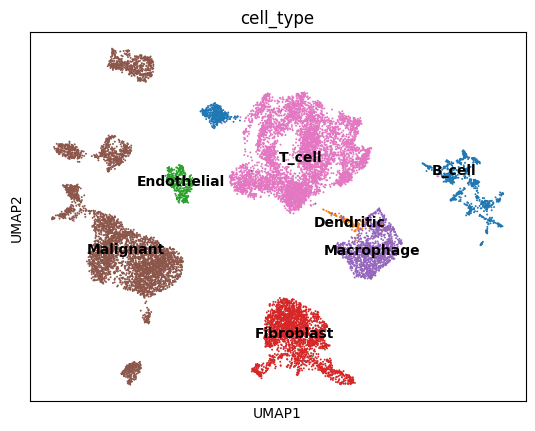

In [19]:
adata_hvg = adata_qian.copy()

# Step 1: Select highly variable genes
sc.pp.highly_variable_genes(adata_hvg, n_top_genes=1000, batch_key="sample")
hvg_genes = adata_hvg.var[adata_hvg.var['highly_variable']].index.to_list()
pd.Series(hvg_genes).to_csv(f"Qian_hvg1000_genes.csv", index=False, header=['gene'])
adata_hvg = adata_hvg[:, adata_hvg.var['highly_variable']].copy()

# Step 2: PCA
sc.tl.pca(adata_hvg, svd_solver='arpack')

# Step 3: Compute neighbors
sc.pp.neighbors(adata_hvg)
sc.tl.umap(adata_hvg)

sc.tl.leiden(adata_hvg, flavor="igraph")
sc.pl.umap(
    adata_hvg,
    color=['cell_type'],
    legend_loc="on data",
    show=True,
    save=f"Qian_hvg1000_genes_umap.png"
)

# Step 6: Find top 20 marker genes for each cluster
sc.tl.rank_genes_groups(adata_hvg, groupby='cell_type', method='wilcoxon')
markers = adata_hvg.uns['rank_genes_groups']
groups = markers['names'].dtype.names
top20_list = []
for g in groups:
    df = pd.DataFrame({g: markers['names'][g][:20]})
    top20_list.append(df)
top20 = pd.concat(top20_list, axis=1)
top20.to_csv(f"Qian_hvg1000_top20_genes.csv", index=False)

In [ ]:
adata_hvg = adata_wu.copy()

# Step 1: Select highly variable genes
sc.pp.highly_variable_genes(adata_hvg, n_top_genes=1000, batch_key="sample")
hvg_genes = adata_hvg.var[adata_hvg.var['highly_variable']].index.to_list()
pd.Series(hvg_genes).to_csv(f"Wu_hvg1000_genes.csv", index=False, header=['gene'])
adata_hvg = adata_hvg[:, adata_hvg.var['highly_variable']].copy()

# Step 2: PCA
sc.tl.pca(adata_hvg, svd_solver='arpack')

# Step 3: Compute neighbors
sc.pp.neighbors(adata_hvg)
sc.tl.umap(adata_hvg)

sc.tl.leiden(adata_hvg, flavor="igraph")
sc.pl.umap(
    adata_hvg,
    color=['cell_type'],
    legend_loc="on data",
    show=False,
    save=f"Wu_hvg1000_genes_umap.png"
)

# Step 6: Find top 20 marker genes for each cluster
sc.tl.rank_genes_groups(adata_hvg, groupby='cell_type', method='wilcoxon')
markers = adata_hvg.uns['rank_genes_groups']
groups = markers['names'].dtype.names
top20_list = []
for g in groups:
    df = pd.DataFrame({g: markers['names'][g][:20]})
    top20_list.append(df)
top20 = pd.concat(top20_list, axis=1)
top20.to_csv(f"Wu_hvg1000_top20_genes.csv", index=False)